# LIBRARIES

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, classification_report,
                             confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
import xgboost as xgb
import shap

pd.set_option('display.max_columns', 200)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# LOADING DATASET

In [3]:
df = pd.read_csv(r"WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)

Shape: (7043, 21)


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
if 'Churn' in df.columns:
    print("\nChurn distribution:")
    print(df['Churn'].value_counts())


Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


# CLEANING

In [8]:
if 'TotalCharges' in df.columns and df['TotalCharges'].dtype == 'object':
    df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', np.nan)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
    print("Converted TotalCharges, missing:", df['TotalCharges'].isnull().sum())

Converted TotalCharges, missing: 11


In [9]:
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

In [10]:
df = df.replace({'No internet service': 'No', 'No phone service': 'No'})

In [11]:
if df['TotalCharges'].isnull().sum() > 0:
    df.loc[df['TotalCharges'].isnull(), 'TotalCharges'] = df['MonthlyCharges'] * df['tenure']
    print("Filled TotalCharges missing with MonthlyCharges*tenure")

Filled TotalCharges missing with MonthlyCharges*tenure


# BASIC EDA

In [12]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print("Numerical cols:", num_cols)
print("Categorical cols:", cat_cols)

Numerical cols: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical cols: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


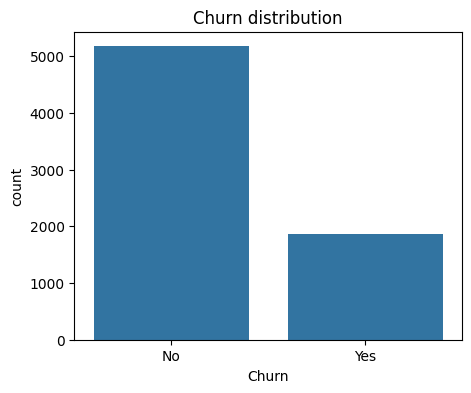

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn distribution")
plt.show()

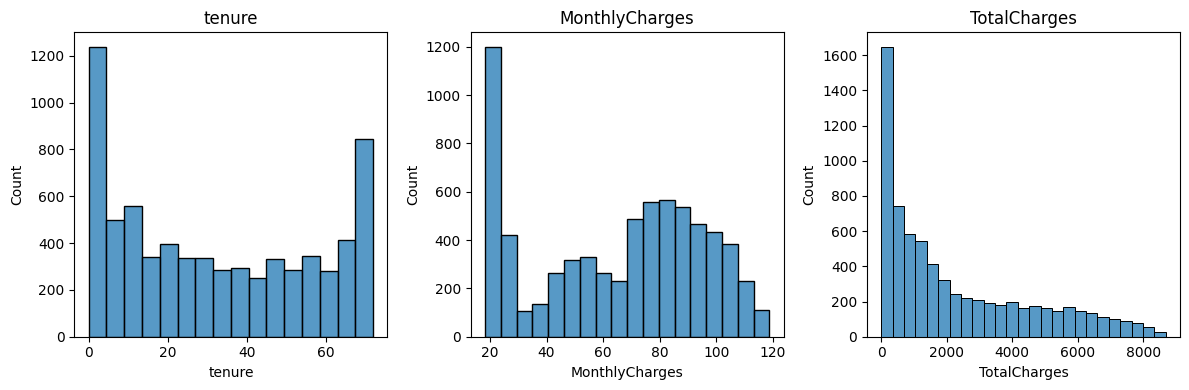

In [14]:
plt.figure(figsize=(12,4))
for i, c in enumerate(['tenure','MonthlyCharges','TotalCharges']):
    plt.subplot(1,3,i+1)
    sns.histplot(df[c].dropna(), kde=False)
    plt.title(c)
plt.tight_layout()
plt.show()

# FEATURE ENGINEERING

In [15]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1,0,12,24,48,60,100], labels=['0','1-12','13-24','25-48','49-60','61+'])

In [16]:
df['AvgChargePerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

In [17]:
df['Churn_flag'] = df['Churn'].map({'Yes':1, 'No':0})

In [18]:
df.drop(columns=['Churn'], inplace=True)

# TRAIN-TEST-SPLIT

In [19]:
target = 'Churn_flag'

In [20]:
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (5634, 21) Test shape: (1409, 21)


In [21]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

In [22]:
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

In [23]:
if 'tenure_group' in X_train.columns and 'tenure_group' not in cat_cols:
    cat_cols.append('tenure_group')
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargePerMonth']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


# PREPROCESSING PIPELINES

In [24]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [25]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [26]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop', sparse_threshold=0)

# LOGISTIC REGRESSION

In [27]:
lr_pipe = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print("LogReg ROC-AUC CV mean: %.4f (std %.4f)" % (scores.mean(), scores.std()))

LogReg ROC-AUC CV mean: 0.8481 (std 0.0116)


In [29]:
lr_pipe.fit(X_train, y_train)
y_pred = lr_pipe.predict(X_test)
y_proba = lr_pipe.predict_proba(X_test)[:,1]
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Test ROC-AUC: 0.8460926399545325
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



# RANDOM FOREST

In [30]:
rf_pipe = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE))
])

In [31]:
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:,1]
print("RF Test ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

RF Test ROC-AUC: 0.8238265002970885
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



# XGBOOST

In [32]:
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)

In [33]:
xgb_pipe = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', xgb_clf)
])

In [34]:
param_dist = {
    'clf__n_estimators': [100, 200, 400],
    'clf__max_depth': [3,5,7],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__reg_alpha': [0, 0.001, 0.01],
}

In [35]:
rs = RandomizedSearchCV(xgb_pipe, param_distributions=param_dist, n_iter=25, scoring='roc_auc',
                        n_jobs=-1, cv=cv, random_state=RANDOM_STATE, verbose=1)
rs.fit(X_train, y_train)
print("Best CV ROC-AUC:", rs.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV ROC-AUC: 0.849146065475443


In [36]:
print("Best params:", rs.best_params_)

Best params: {'clf__subsample': 0.6, 'clf__reg_alpha': 0, 'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.6}


In [37]:
best_xgb = rs.best_estimator_
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]
y_pred_xgb = best_xgb.predict(X_test)
print("XGB Test ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

XGB Test ROC-AUC: 0.8469877806194942


In [38]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



# COMPARING MODELS

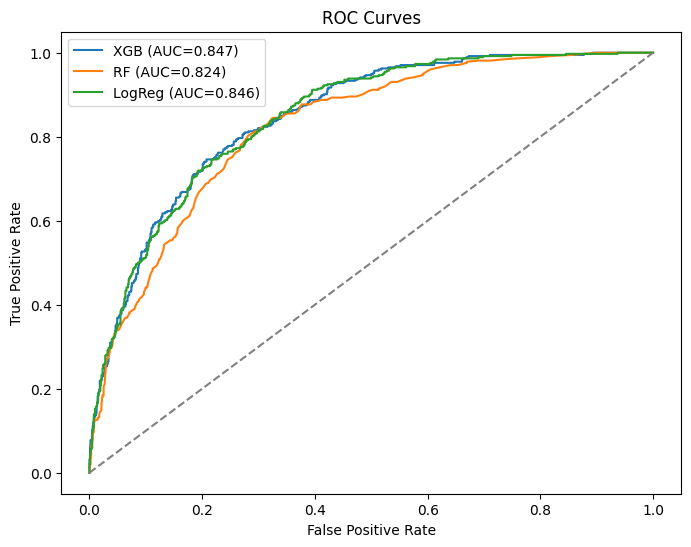

In [39]:
plt.figure(figsize=(8,6))
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr, tpr, label=f'XGB (AUC={roc_auc_score(y_test,y_proba_xgb):.3f})')
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test,y_proba_rf):.3f})')
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC={roc_auc_score(y_test,y_proba):.3f})')
plt.plot([0,1],[0,1],'--', color='grey')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(); plt.show()

# METRIC TABLE

In [40]:
from sklearn.metrics import precision_recall_fscore_support

def best_threshold_by(metric, probs, y_true, thresholds=np.linspace(0.01,0.99,99)):
    best = {'metric': -1, 'threshold': None}
    for t in thresholds:
        preds = (probs >= t).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, preds)
        elif metric == 'precision':
            score = precision_score(y_true, preds)
        elif metric == 'recall':
            score = recall_score(y_true, preds)
        else:
            raise ValueError("metric must be one of 'f1','precision','recall'")
        if score > best['metric']:
            best = {'metric': score, 'threshold': t}
    return best

best_f1 = best_threshold_by('f1', y_proba_xgb, y_test)
print("Best threshold by F1:", best_f1)

Best threshold by F1: {'metric': 0.6412918108419838, 'threshold': np.float64(0.34)}


In [41]:
summary_data = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost (Final Model)"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
}

model_comparison_df = pd.DataFrame(summary_data)
model_comparison_df

,Model,ROC-AUC,Precision,Recall,F1-Score
0,Logistic Regression,0.846093,0.507772,0.786096,0.616999
1,Random Forest,0.823827,0.608108,0.481283,0.537313
2,XGBoost (Final Model),0.846988,0.672662,0.500000,0.573620


In [42]:
best_model_name = model_comparison_df.loc[model_comparison_df["ROC-AUC"].idxmax(), "Model"]
best_model_name

'XGBoost (Final Model)'